# 01 · Análisis exploratorio (EDA) — Predictor UFC

Exploración de los datos crudos scrapeados de ufcstats.com: crecimiento de la UFC, cómo se resuelven las peleas y atributos de los peleadores.

> Los datos se generan con `python -m src.scraping.scraper`.

In [1]:
from pathlib import Path
import sys
root = Path.cwd()
if not (root / 'config.py').exists():
    root = root.parent
sys.path.insert(0, str(root))
import pandas as pd, numpy as np, matplotlib.pyplot as plt
import config
plt.rcParams['figure.figsize'] = (9, 4)
plt.rcParams['axes.grid'] = True


In [2]:
events = pd.read_csv(config.EVENTS_CSV, parse_dates=['date'])
fights = pd.read_csv(config.FIGHTS_CSV, parse_dates=['date'])
fighters = pd.read_csv(config.FIGHTERS_CSV, parse_dates=['dob'])
stats = pd.read_csv(config.FIGHT_STATS_CSV)
print(f'eventos: {len(events)} | peleas: {len(fights)} | peleadores: {len(fighters)} | stats: {len(stats)}')
print('rango:', events.date.min().date(), '->', events.date.max().date())

eventos: 780 | peleas: 8772 | peleadores: 2712 | stats: 17502
rango: 1994-03-11 -> 2026-07-11


## Crecimiento de la UFC
Cuántos eventos hubo por año.

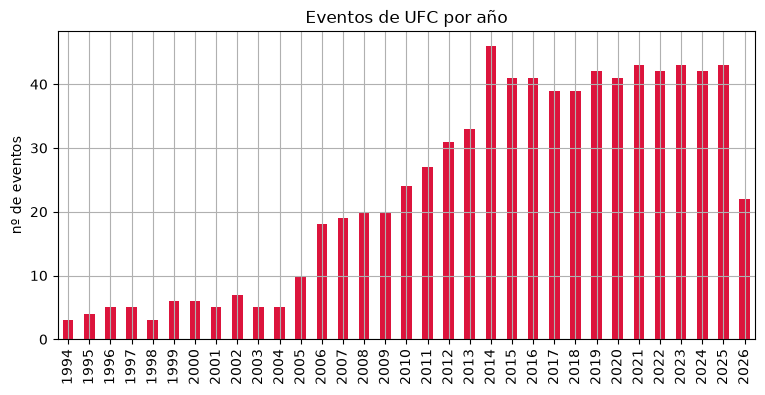

In [3]:
events['year'] = events.date.dt.year
events.groupby('year').size().plot(kind='bar', color='crimson')
plt.title('Eventos de UFC por año'); plt.ylabel('nº de eventos'); plt.xlabel(''); plt.show()

## ¿Cómo se resuelven las peleas?
Distribución del método de victoria (nuestro segundo objetivo a predecir).

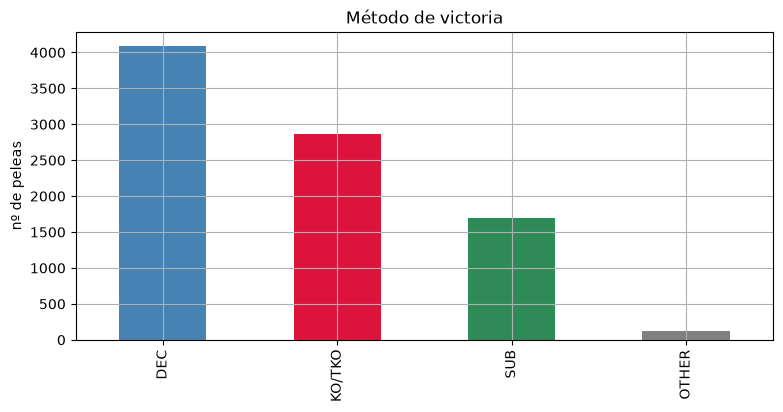

method
DEC       4083
KO/TKO    2870
SUB       1702
OTHER      117
Name: count, dtype: int64

In [4]:
mc = fights.method.value_counts()
mc.plot(kind='bar', color=['steelblue', 'crimson', 'seagreen', 'gray'])
plt.title('Método de victoria'); plt.ylabel('nº de peleas'); plt.xlabel(''); plt.show()
mc

### Evolución en el tiempo
¿La UFC tiene hoy más decisiones y menos finalizaciones que antes?

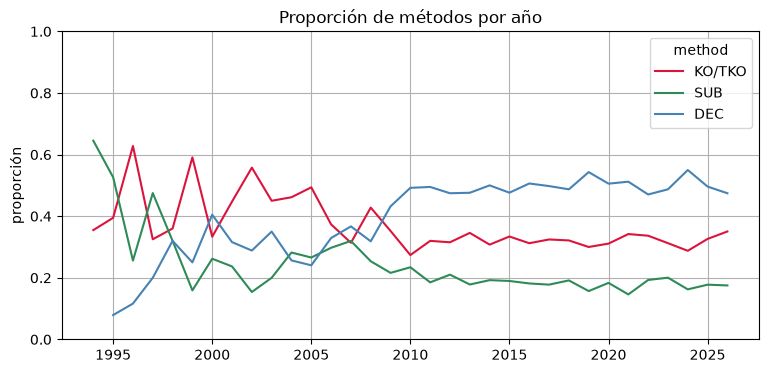

In [5]:
fights['year'] = fights.date.dt.year
share = (fights[fights.method != 'OTHER']
         .groupby('year').method.value_counts(normalize=True).unstack()
         .reindex(columns=['KO/TKO', 'SUB', 'DEC']))
share.plot(color=['crimson', 'seagreen', 'steelblue'])
plt.title('Proporción de métodos por año'); plt.ylabel('proporción'); plt.ylim(0, 1)
plt.xlabel(''); plt.show()

## ¿En qué round terminan las finalizaciones?

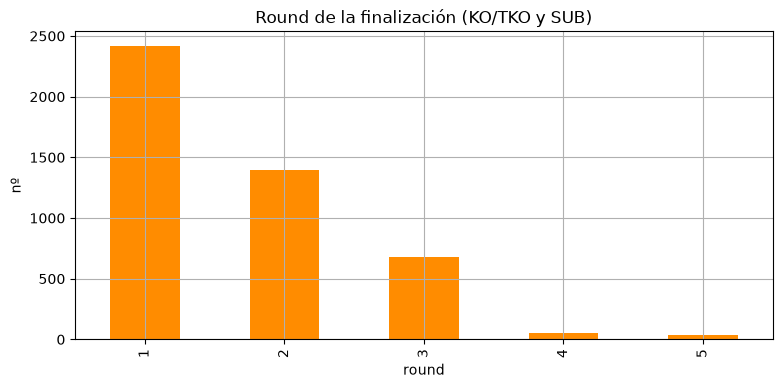

In [6]:
fin = fights[fights.method.isin(['KO/TKO', 'SUB'])]
fin['round'].value_counts().sort_index().plot(kind='bar', color='darkorange')
plt.title('Round de la finalización (KO/TKO y SUB)'); plt.xlabel('round'); plt.ylabel('nº'); plt.show()

## Categorías de peso más frecuentes

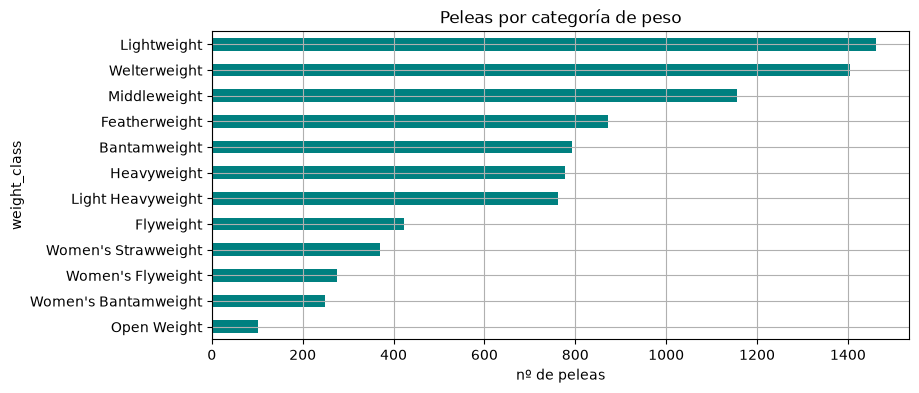

In [7]:
fights.weight_class.replace('', np.nan).value_counts().head(12).plot(kind='barh', color='teal')
plt.title('Peleas por categoría de peso'); plt.gca().invert_yaxis(); plt.xlabel('nº de peleas'); plt.show()

## Atributos físicos de los peleadores
Altura, alcance y edad. Nota el **alcance falta en ~24%** de las fichas — un reto de datos que el modelo maneja gracias a que LightGBM soporta valores nulos nativamente.

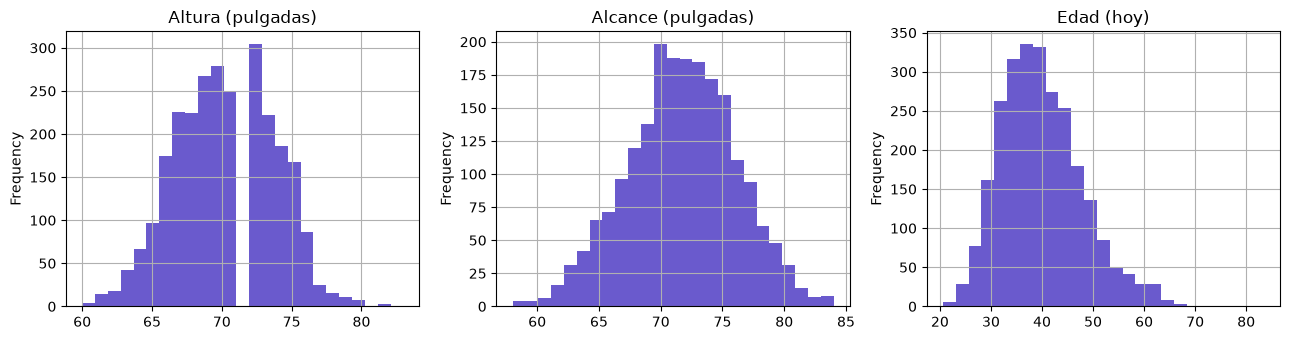

% de nulos por columna:


height_in     0.8
reach_in     24.2
stance        3.0
dob           3.8
dtype: float64

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.5))
fighters.height_in.dropna().plot(kind='hist', bins=25, ax=ax[0], color='slateblue', title='Altura (pulgadas)')
fighters.reach_in.dropna().plot(kind='hist', bins=25, ax=ax[1], color='slateblue', title='Alcance (pulgadas)')
age = (pd.Timestamp('today') - fighters.dob).dt.days / 365.25
age.dropna().plot(kind='hist', bins=25, ax=ax[2], color='slateblue', title='Edad (hoy)')
plt.tight_layout(); plt.show()
print('% de nulos por columna:')
(fighters[['height_in', 'reach_in', 'stance', 'dob']].isna().mean() * 100).round(1)

## Conclusiones
- La UFC creció enormemente: de unos pocos eventos en los 90 a ~40/año hoy.
- **La decisión (DEC) es el resultado más común**, seguida de KO/TKO y sumisión.
- Las finalizaciones se concentran en los primeros rounds.
- Hay datos faltantes reales (alcance, fecha de nacimiento) que el pipeline trata sin imputación forzada.

Estos patrones justifican el diseño del modelo (predecir ganador + método) y el cuidado con los datos faltantes.